## Data Preprocessing

In [2]:
import pandas as pd
file_path = "/Users/yaocaiping/Desktop/KM/KM6312_ INFORMATION MINING & ANALYSIS/Final Project/cleaned_creditcard.csv"
df = pd.read_csv(file_path)
df_info = df.info()
df_head = df.head()
df_class_distribution = df["Class"].value_counts()

df_info, df_head, df_class_distribution

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283726 entries, 0 to 283725
Data columns (total 32 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Time        283726 non-null  float64
 1   V1          283726 non-null  float64
 2   V2          283726 non-null  float64
 3   V3          283726 non-null  float64
 4   V4          283726 non-null  float64
 5   V5          283726 non-null  float64
 6   V6          283726 non-null  float64
 7   V7          283726 non-null  float64
 8   V8          283726 non-null  float64
 9   V9          283726 non-null  float64
 10  V10         283726 non-null  float64
 11  V11         283726 non-null  float64
 12  V12         283726 non-null  float64
 13  V13         283726 non-null  float64
 14  V14         283726 non-null  float64
 15  V15         283726 non-null  float64
 16  V16         283726 non-null  float64
 17  V17         283726 non-null  float64
 18  V18         283726 non-null  float64
 19  V1

(None,
    Time        V1        V2        V3        V4        V5        V6        V7  \
 0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
 1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
 2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
 3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
 4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   
 
          V8        V9  ...       V22       V23       V24       V25       V26  \
 0  0.098698  0.363787  ...  0.277838 -0.110474  0.066928  0.128539 -0.189115   
 1  0.085102 -0.255425  ... -0.638672  0.101288 -0.339846  0.167170  0.125895   
 2  0.247676 -1.514654  ...  0.771679  0.909412 -0.689281 -0.327642 -0.139097   
 3  0.377436 -1.387024  ...  0.005274 -0.190321 -1.175575  0.647376 -0.221929   
 4 -0.270533  0.817739  ...  0.798278 -0.137458  0.141267 -0.206010  0.502292   
 
         V2

In [4]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from collections import Counter
import matplotlib.pyplot as plt
import random

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
rng = np.random.RandomState(RANDOM_SEED)

file_path = "/Users/yaocaiping/Desktop/KM/KM6312_ INFORMATION MINING & ANALYSIS/Final Project/cleaned_creditcard.csv"
df = pd.read_csv(file_path)

if 'Class' not in df.columns:
    raise ValueError("Dataset must have a 'Class' column indicating fraud (1) or non-fraud (0).")

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

X_train_resampled = pd.DataFrame(X_train_resampled, columns=X.columns)

print("Class distribution AFTER SMOTE:", Counter(y_train_resampled))

fraud_indices = np.where(y_train_resampled == 1)[0] 

amount_col = 'Amount'
if amount_col in X_train_resampled.columns:
    noise = rng.uniform(-0.05, 0.05, size=len(fraud_indices)) 
    X_train_resampled.loc[fraud_indices, amount_col] *= (1 + noise)

time_col = 'Time_Hours'
if time_col in X_train_resampled.columns:
    time_shift = rng.randint(-2, 3, size=len(fraud_indices))
    X_train_resampled.loc[fraud_indices, time_col] += time_shift
    X_train_resampled[time_col] = X_train_resampled[time_col].clip(lower=0, upper=24) 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test) 

print("Mean of first few scaled features:", np.mean(X_train_scaled, axis=0))
print("Standard deviation of first few scaled features:", np.std(X_train_scaled, axis=0)[:5])
print(X_train_resampled.head())

Class distribution AFTER SMOTE: Counter({0: 226602, 1: 226602})
Mean of first few scaled features: [ 6.69773119e-17  7.22451904e-17  3.51191898e-17 -3.91328115e-17
 -4.21430277e-17  1.75595949e-17 -1.11879705e-16  8.82996771e-17
 -1.25425678e-19  7.97707311e-17 -1.01343948e-16  3.66242979e-17
  0.00000000e+00  1.62543839e-17 -1.20408651e-17 -2.05698112e-17
  1.89643625e-16  5.81975145e-17  5.36821901e-17 -3.78785547e-17
  6.67264606e-17  4.76617575e-18  2.96004599e-17  1.17900137e-17
  1.90647030e-17  1.55998187e-18  2.19494936e-18  1.35459732e-17
  7.83910486e-18  3.71510858e-16 -2.18742382e-16]
Standard deviation of first few scaled features: [1. 1. 1. 1. 1.]
       Time        V1        V2        V3        V4        V5        V6  \
0  144549.0  2.238954 -1.724499 -2.151484 -2.577803  0.993668  3.565492   
1   80716.0 -1.315062  1.630783  0.597001 -0.038359 -0.404580 -0.965712   
2  127116.0  1.908801  0.021184 -2.087997  0.129310  1.161468  0.605244   
3   91342.0  1.811257  0.31655

## Model Evaluation

### Original Model

In [6]:
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train_scaled, y_train_resampled)
y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]
print("\nXGBoost Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_xgb):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.4f}")


XGBoost Performance:
Accuracy: 0.9995
Precision: 0.8736
Recall: 0.8000
F1-score: 0.8352
AUC-ROC: 0.9688


### Stage 1 

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, \
    precision_recall_curve
import numpy as np
import pandas as pd
from xgboost import XGBClassifier

def find_optimal_threshold(y_true, y_prob, target_precision=0.8):
    """Find the optimal threshold to balance precision and recall"""
    precision_curve, recall_curve, thresholds = precision_recall_curve(y_true, y_prob)
    
    # Add 1.0 to thresholds for the last precision/recall point
    thresholds = np.append(thresholds, 1.0)
    
    # Initialize variables
    best_f1 = 0
    best_threshold = 0.5
    best_precision = 0
    best_recall = 0
    
    # Find threshold that gives highest F1 score while meeting target precision
    for i, (p, r, t) in enumerate(zip(precision_curve, recall_curve, thresholds)):
        if p >= target_precision:
            f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
            if f1 > best_f1:
                best_f1 = f1
                best_threshold = t
                best_precision = p
                best_recall = r
    
    # If no threshold meets target precision, find one with best balance
    if best_threshold == 0.5 and best_f1 == 0:
        f1_scores = np.zeros_like(precision_curve)
        for i, (p, r) in enumerate(zip(precision_curve, recall_curve)):
            f1_scores[i] = 2 * p * r / (p + r) if (p + r) > 0 else 0
        
        best_idx = np.argmax(f1_scores)
        best_threshold = thresholds[best_idx]
        best_precision = precision_curve[best_idx]
        best_recall = recall_curve[best_idx]
        best_f1 = f1_scores[best_idx]
    
    return {
        'threshold': best_threshold,
        'precision': best_precision,
        'recall': best_recall,
        'f1_score': best_f1
    }

def evaluate_model(model, X_test, y_test, threshold=None, target_precision=0.8):
    """Evaluate model performance, finding optimal threshold if not provided"""
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Find optimal threshold if not provided
    if threshold is None:
        threshold_metrics = find_optimal_threshold(y_test, y_prob, target_precision)
        threshold = threshold_metrics['threshold']
    
    # Make predictions with the threshold
    y_pred = (y_prob >= threshold).astype(int)
    
    # Calculate metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    return {
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'accuracy': accuracy,
        'auc_roc': auc
    }

# Generate more focused parameter combinations
def generate_focused_params():
    params = []
    
    # Start with default XGBoost parameters that performed well
    base_params = {
        'max_depth': 6,
        'learning_rate': 0.1,
        'n_estimators': 100,
        'subsample': 0.9,
        'colsample_bytree': 0.9,
        'scale_pos_weight': 1,
        'min_child_weight': 1,
        'gamma': 0
    }
    
    # Add the default parameters that worked well
    params.append(base_params.copy())
    
    # Add variations on max_depth and n_estimators
    for depth in [5, 7, 8]:
        for n_est in [150, 200]:
            p = base_params.copy()
            p['max_depth'] = depth
            p['n_estimators'] = n_est
            params.append(p)
    
    # Try different learning rates
    for lr in [0.03, 0.05]:
        p = base_params.copy()
        p['learning_rate'] = lr
        params.append(p)
    
    # Try different regularization combinations
    for gamma in [0, 0.1]:
        for min_child in [1, 2]:
            p = base_params.copy()
            p['gamma'] = gamma
            p['min_child_weight'] = min_child
            params.append(p)
    
    # Try different sampling parameters
    for subsample in [0.8, 1.0]:
        for colsample in [0.8, 1.0]:
            p = base_params.copy()
            p['subsample'] = subsample
            p['colsample_bytree'] = colsample
            params.append(p)
    
    print(f"Generated {len(params)} focused parameter combinations")
    return params

# Get parameter list
param_list = generate_focused_params()

# Store results
results = []

# Train and evaluate models with different parameters
for i, params in enumerate(param_list):
    print(f"\nEvaluating combination {i+1}/{len(param_list)}: max_depth={params['max_depth']}, "
          f"n_estimators={params['n_estimators']}, learning_rate={params['learning_rate']}")
    
    # Create and train model
    model = XGBClassifier(
        max_depth=params['max_depth'],
        learning_rate=params['learning_rate'],
        n_estimators=params['n_estimators'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        scale_pos_weight=params['scale_pos_weight'],
        min_child_weight=params['min_child_weight'],
        gamma=params['gamma'],
        eval_metric='logloss',
        random_state=42
    )
    
    model.fit(X_train_scaled, y_train_resampled)
    
    # Evaluate model with target precision of 0.8
    metrics = evaluate_model(model, X_test_scaled, y_test, target_precision=0.8)
    
    # Add model parameters to results
    metrics.update(params)
    
    results.append(metrics)
    
    print(f"  Precision: {metrics['precision']:.4f}, Recall: {metrics['recall']:.4f}, "
          f"F1 Score: {metrics['f1_score']:.4f}")

# Convert results to DataFrame
results_df_stage1 = pd.DataFrame(results)

# Find best model by sorting on F1 score
best_model_params = results_df_stage1.sort_values('f1_score', ascending=False).iloc[0]

print("\nBest parameter combination:")
for param, value in best_model_params.items():
    if param in ['max_depth', 'n_estimators', 'learning_rate', 'scale_pos_weight',
                 'subsample', 'colsample_bytree', 'precision', 'recall', 'f1_score']:
        print(f"  {param}: {value:.4f}" if isinstance(value, float) else f"  {param}: {value}")

# Train final model with best parameters
final_model = XGBClassifier(
    max_depth=int(best_model_params['max_depth']),
    learning_rate=best_model_params['learning_rate'],
    n_estimators=int(best_model_params['n_estimators']),
    subsample=best_model_params['subsample'],
    colsample_bytree=best_model_params['colsample_bytree'],
    scale_pos_weight=int(best_model_params['scale_pos_weight']),
    min_child_weight=int(best_model_params['min_child_weight']),
    gamma=best_model_params['gamma'],
    eval_metric='logloss',
    random_state=42
)

# Train final model
print("\nTraining final model...")
final_model.fit(X_train_scaled, y_train_resampled)

# Apply the optimal threshold found
optimal_threshold = best_model_params['threshold']
y_prob = final_model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= optimal_threshold).astype(int)

# Evaluate final model
print("\nFinal Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Optimal Threshold: {optimal_threshold:.4f}")

Generated 17 focused parameter combinations

Evaluating combination 1/17: max_depth=6, n_estimators=100, learning_rate=0.1
  Precision: 0.8929, Recall: 0.7895, F1 Score: 0.8380

Evaluating combination 2/17: max_depth=5, n_estimators=150, learning_rate=0.1
  Precision: 0.9136, Recall: 0.7789, F1 Score: 0.8409

Evaluating combination 3/17: max_depth=5, n_estimators=200, learning_rate=0.1
  Precision: 0.9259, Recall: 0.7895, F1 Score: 0.8523

Evaluating combination 4/17: max_depth=7, n_estimators=150, learning_rate=0.1
  Precision: 0.9259, Recall: 0.7895, F1 Score: 0.8523

Evaluating combination 5/17: max_depth=7, n_estimators=200, learning_rate=0.1
  Precision: 0.9375, Recall: 0.7895, F1 Score: 0.8571

Evaluating combination 6/17: max_depth=8, n_estimators=150, learning_rate=0.1
  Precision: 0.9494, Recall: 0.7895, F1 Score: 0.8621

Evaluating combination 7/17: max_depth=8, n_estimators=200, learning_rate=0.1
  Precision: 0.9494, Recall: 0.7895, F1 Score: 0.8621

Evaluating combination 8

# Stage 2

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, \
    precision_recall_curve
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
import itertools

def find_optimal_threshold_recall_focused(y_true, y_prob, min_precision=0.75, recall_weight=2):
    """Find threshold that balances precision and recall with a bias toward recall"""
    precision_curve, recall_curve, thresholds = precision_recall_curve(y_true, y_prob)
    
    # Add 1.0 to thresholds for the last precision/recall point
    thresholds = np.append(thresholds, 1.0)
    
    # Initialize variables
    best_score = 0
    best_threshold = 0.5
    best_precision = 0
    best_recall = 0
    
    # Calculate weighted F-score with emphasis on recall
    for i, (p, r, t) in enumerate(zip(precision_curve, recall_curve, thresholds)):
        # Only consider thresholds where precision meets minimum requirement
        if p >= min_precision:
            # Calculate F-beta score with beta=recall_weight
            if p > 0 and r > 0:
                beta_squared = recall_weight * recall_weight
                score = (1 + beta_squared) * p * r / (beta_squared * p + r)
                
                if score > best_score:
                    best_score = score
                    best_threshold = t
                    best_precision = p
                    best_recall = r
    
    # If no threshold meets criteria, find threshold with best balance
    if best_threshold == 0.5 and best_score == 0:
        # Fall back to standard F1 score but look for highest recall meeting min precision
        for i, (p, r, t) in enumerate(zip(precision_curve, recall_curve, thresholds)):
            if p >= min_precision and r > best_recall:
                best_threshold = t
                best_precision = p
                best_recall = r
                best_score = 2 * p * r / (p + r) if (p + r) > 0 else 0
    
    return {
        'threshold': best_threshold,
        'precision': best_precision,
        'recall': best_recall,
        'f1_score': 2 * best_precision * best_recall / (best_precision + best_recall) 
                    if (best_precision + best_recall) > 0 else 0
    }

def evaluate_model_recall_focused(model, X_test, y_test, threshold=None, min_precision=0.75):
    """Evaluate model with focus on maximizing recall while maintaining minimum precision"""
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Find optimal threshold if not provided
    if threshold is None:
        threshold_metrics = find_optimal_threshold_recall_focused(y_test, y_prob, min_precision)
        threshold = threshold_metrics['threshold']
    
    # Make predictions with the threshold
    y_pred = (y_prob >= threshold).astype(int)
    
    # Calculate metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    return {
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'accuracy': accuracy,
        'auc_roc': auc
    }

# Generate recall-focused parameter combinations
def generate_recall_focused_params():
    """Generate parameter combinations focused on improving recall with extensive cross-combinations"""
    
    # Base parameters from previous best model
    base_params = {
        'max_depth': 8,
        'learning_rate': 0.1,
        'n_estimators': 200,
        'subsample': 0.9,
        'colsample_bytree': 0.9,
        'scale_pos_weight': 1,
        'min_child_weight': 1,
        'gamma': 0
    }
    
    # Define multiple candidate values for each parameter
    param_grid = {
        'max_depth': [7, 8, 9, 10],
        'learning_rate': [0.05, 0.1, 0.15, 0.2],
        'n_estimators': [100, 200, 300, 400],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
        'scale_pos_weight': [1, 3, 5, 10],
        'min_child_weight': [1, 2, 3],
        'gamma': [0, 0.1, 0.2]
    }
    
    params = []
    
    # 1. Add Base Parameter Combination
    params.append(base_params.copy())
    
    # 2. Create some focused combinations to control the total number of combinations
    # 2.1 Try different tree depth and estimator count combinations
    depth_estimators = list(itertools.product(param_grid['max_depth'], param_grid['n_estimators']))
    for depth, n_est in depth_estimators:
        p = base_params.copy()
        p['max_depth'] = depth
        p['n_estimators'] = n_est
        params.append(p)
    
    # 2.2 Try different learning rate and scale_pos_weight combinations
    lr_spw = list(itertools.product(param_grid['learning_rate'], param_grid['scale_pos_weight']))
    for lr, spw in lr_spw:
        p = base_params.copy()
        p['learning_rate'] = lr
        p['scale_pos_weight'] = spw
        params.append(p)
    
    # 2.3 Try different subsample and column sample combinations
    subsample_colsample = list(itertools.product(param_grid['subsample'], param_grid['colsample_bytree']))
    for ss, cs in subsample_colsample:
        p = base_params.copy()
        p['subsample'] = ss
        p['colsample_bytree'] = cs
        params.append(p)
    
    # 2.4 Try different regularization parameter combinations
    reg_params = list(itertools.product(param_grid['min_child_weight'], param_grid['gamma']))
    for mcw, gamma in reg_params:
        p = base_params.copy()
        p['min_child_weight'] = mcw
        p['gamma'] = gamma
        params.append(p)
    
    # 3. Add some special combinations optimized for recall
    # 3.1 High depth, high learning rate, high positive class weight
    recall_focused_combos = list(itertools.product(
        [9, 10], 
        [0.15, 0.2],  
        [5, 10]  
    ))
    
    for depth, lr, spw in recall_focused_combos:
        p = base_params.copy()
        p['max_depth'] = depth
        p['learning_rate'] = lr
        p['scale_pos_weight'] = spw
        p['n_estimators'] = 300  
        params.append(p)
    
    # 3.2 Add some extreme combinations focused on maximizing recall
    # Deepest tree, high learning rate, high positive class weight, maximum estimators
    extreme_recall_params = base_params.copy()
    extreme_recall_params['max_depth'] = 10
    extreme_recall_params['learning_rate'] = 0.2
    extreme_recall_params['n_estimators'] = 400
    extreme_recall_params['scale_pos_weight'] = 10
    extreme_recall_params['subsample'] = 1.0
    extreme_recall_params['colsample_bytree'] = 1.0
    params.append(extreme_recall_params)
    
    # 3.3 Try more cross-combinations
    # Cross-combinations of depth and learning rate
    for depth in [9, 10]:
        for lr in [0.15, 0.2]:
            p = base_params.copy()
            p['max_depth'] = depth
            p['learning_rate'] = lr
            p['n_estimators'] = 300
            params.append(p)
    
    # Cross-combinations of learning rate and estimator count
    for lr in [0.1, 0.15]:
        for n_est in [200, 300, 400]:
            p = base_params.copy()
            p['learning_rate'] = lr
            p['n_estimators'] = n_est
            params.append(p)
    
    # 4. Add some combinations that might perform well in edge cases
    # 4.1 Low depth but high estimator count
    low_depth_high_estimators = base_params.copy()
    low_depth_high_estimators['max_depth'] = 5
    low_depth_high_estimators['n_estimators'] = 500
    low_depth_high_estimators['learning_rate'] = 0.05
    params.append(low_depth_high_estimators)
    
    # 4.2 High depth but low learning rate (to prevent overfitting)
    high_depth_low_lr = base_params.copy()
    high_depth_low_lr['max_depth'] = 10
    high_depth_low_lr['learning_rate'] = 0.05
    high_depth_low_lr['n_estimators'] = 400
    params.append(high_depth_low_lr)
    
    # Remove any duplicates
    unique_params = []
    seen = set()
    for p in params:
        param_tuple = tuple(sorted(p.items()))
        if param_tuple not in seen:
            seen.add(param_tuple)
            unique_params.append(p)
    
    print(f"Generated {len(unique_params)} recall-focused parameter combinations")
    return unique_params

print("\n-------- Using Recall-Focused Parameter Tuning Method --------")
print("Generating more targeted parameter combinations...")
recall_focused_params = generate_recall_focused_params()

# Set minimum acceptable precision
min_precision = 0.75

print(f"\nStarting model training and evaluation (minimum precision: {min_precision})...")
# Get parameter list
param_list = recall_focused_params

# Store results
results = []

# Train and evaluate models with different parameters
for i, params in enumerate(param_list):
    print(f"\nEvaluating combination {i+1}/{len(param_list)}: max_depth={params['max_depth']}, "
          f"n_estimators={params['n_estimators']}, learning_rate={params['learning_rate']}, "
          f"scale_pos_weight={params['scale_pos_weight']}")
    
    # Create and train model
    model = XGBClassifier(
        max_depth=params['max_depth'],
        learning_rate=params['learning_rate'],
        n_estimators=params['n_estimators'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        scale_pos_weight=params['scale_pos_weight'],
        min_child_weight=params['min_child_weight'],
        gamma=params['gamma'],
        eval_metric='logloss',
        random_state=42
    )
    
    model.fit(X_train_scaled, y_train_resampled)
    
    # Evaluate model with recall focus and minimum precision requirement
    metrics = evaluate_model_recall_focused(model, X_test_scaled, y_test, min_precision=min_precision)
    
    # Add model parameters to results
    metrics.update(params)
    
    results.append(metrics)
    
    print(f"  Precision: {metrics['precision']:.4f}, Recall: {metrics['recall']:.4f}, "
          f"F1 Score: {metrics['f1_score']:.4f}")

# Convert results to DataFrame
results_df_stage2 = pd.DataFrame(results)

# Sort results by recall for models meeting precision requirements
high_precision_models = results_df_stage2[results_df_stage2['precision'] >= min_precision]

# MODIFIED SELECTION LOGIC: Sort first by recall (descending), then by F1 score (descending)
if not high_precision_models.empty:
    # First sort by recall, then by F1 score when recall is tied
    best_model_params = high_precision_models.sort_values(['recall', 'f1_score'], ascending=[False, False]).iloc[0]
    print(f"\nFound {len(high_precision_models)} models meeting minimum precision requirement, "
          f"selecting the one with highest recall and F1 score")
else:
    # If no models meet precision requirement, choose best F1
    best_model_params = results_df_stage2.sort_values('f1_score', ascending=False).iloc[0]
    print("\nNo models meet minimum precision requirement, selecting the one with highest F1 score")

print("\nBest parameter combination:")
important_params = ['max_depth', 'n_estimators', 'learning_rate', 'scale_pos_weight',
                   'subsample', 'colsample_bytree', 'precision', 'recall', 'f1_score']
for param, value in best_model_params[important_params].items():
    print(f"  {param}: {value:.4f}" if isinstance(value, float) else f"  {param}: {value}")

# Train final model with best parameters
final_model = XGBClassifier(
    max_depth=int(best_model_params['max_depth']),
    learning_rate=best_model_params['learning_rate'],
    n_estimators=int(best_model_params['n_estimators']),
    subsample=best_model_params['subsample'],
    colsample_bytree=best_model_params['colsample_bytree'],
    scale_pos_weight=int(best_model_params['scale_pos_weight']),
    min_child_weight=int(best_model_params['min_child_weight']),
    gamma=best_model_params['gamma'],
    eval_metric='logloss',
    random_state=42
)

# Train final model
print("\nTraining final model...")
final_model.fit(X_train_scaled, y_train_resampled)

# Apply the optimal threshold found
optimal_threshold = best_model_params['threshold']
y_prob = final_model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= optimal_threshold).astype(int)

# Evaluate final model
print("\nFinal Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Optimal Threshold: {optimal_threshold:.4f}")


-------- Using Recall-Focused Parameter Tuning Method --------
Generating more targeted parameter combinations...
Generated 71 recall-focused parameter combinations

Starting model training and evaluation (minimum precision: 0.75)...

Evaluating combination 1/71: max_depth=8, n_estimators=200, learning_rate=0.1, scale_pos_weight=1
  Precision: 0.9494, Recall: 0.7895, F1 Score: 0.8621

Evaluating combination 2/71: max_depth=7, n_estimators=100, learning_rate=0.1, scale_pos_weight=1
  Precision: 0.8837, Recall: 0.8000, F1 Score: 0.8398

Evaluating combination 3/71: max_depth=7, n_estimators=200, learning_rate=0.1, scale_pos_weight=1
  Precision: 0.8837, Recall: 0.8000, F1 Score: 0.8398

Evaluating combination 4/71: max_depth=7, n_estimators=300, learning_rate=0.1, scale_pos_weight=1
  Precision: 0.8941, Recall: 0.8000, F1 Score: 0.8444

Evaluating combination 5/71: max_depth=7, n_estimators=400, learning_rate=0.1, scale_pos_weight=1
  Precision: 0.8837, Recall: 0.8000, F1 Score: 0.8398


#### Feature Importance and Contribution Analysis

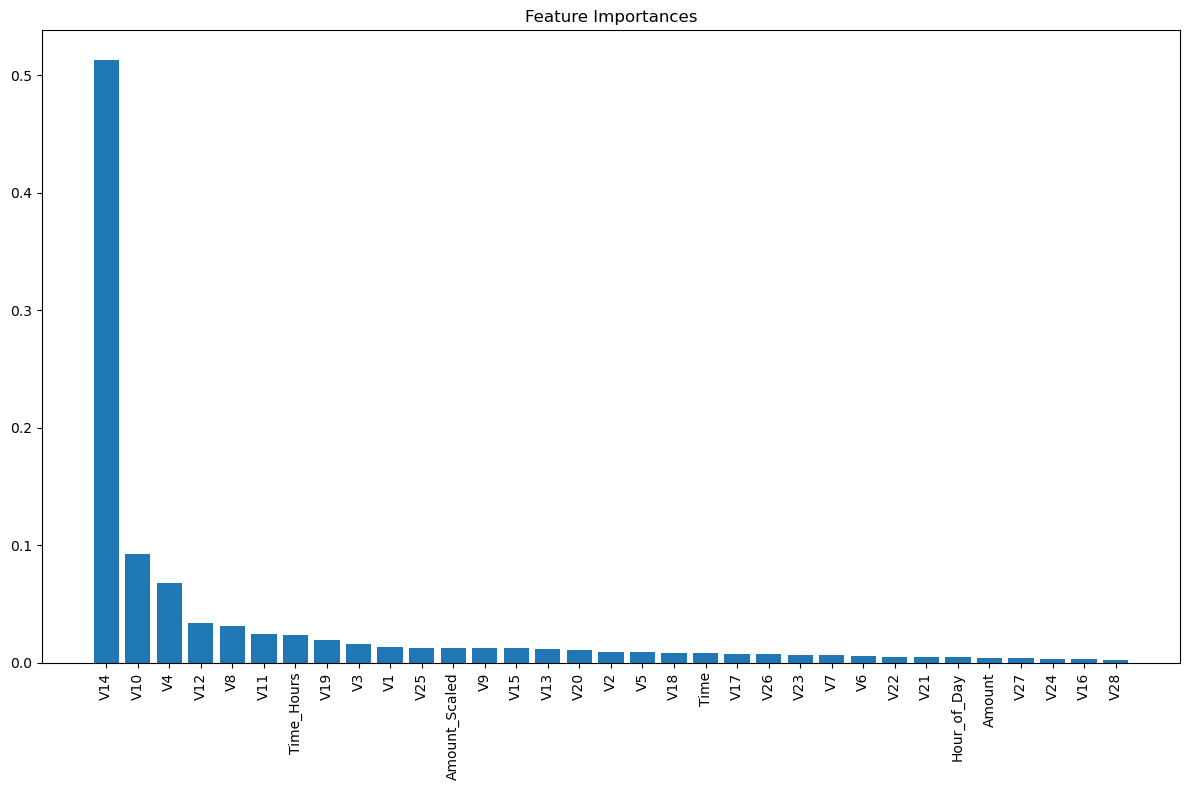

Top 10 most important features:
1. V14 - 0.5125
2. V10 - 0.0920
3. V4 - 0.0678
4. V12 - 0.0339
5. V8 - 0.0309
6. V11 - 0.0243
7. Time_Hours - 0.0232
8. V19 - 0.0192
9. V3 - 0.0154
10. V1 - 0.0130


In [12]:
# Feature Importance Analysis
importance = final_model.feature_importances_
indices = np.argsort(importance)[::-1]

plt.figure(figsize=(12, 8))
plt.title('Feature Importances')
plt.bar(range(X_train.shape[1]), importance[indices], align='center')
plt.xticks(range(X_train.shape[1]), [X_train.columns[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

print("Top 10 most important features:")
for i in range(10):
    print(f"{i+1}. {X_train.columns[indices[i]]} - {importance[indices[i]]:.4f}")

/var/folders/zp/l10d44194b90j_ns2_j8fj5r0000gn/T/ipykernel_40310/1277463071.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_scaled[:sample_size],


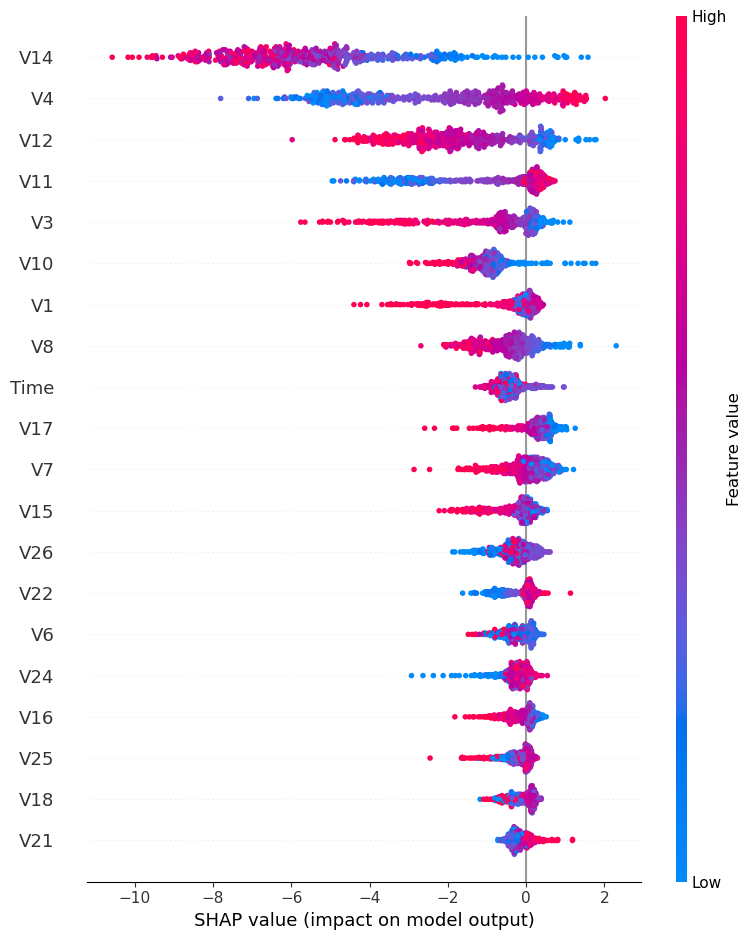

<Figure size 640x480 with 0 Axes>

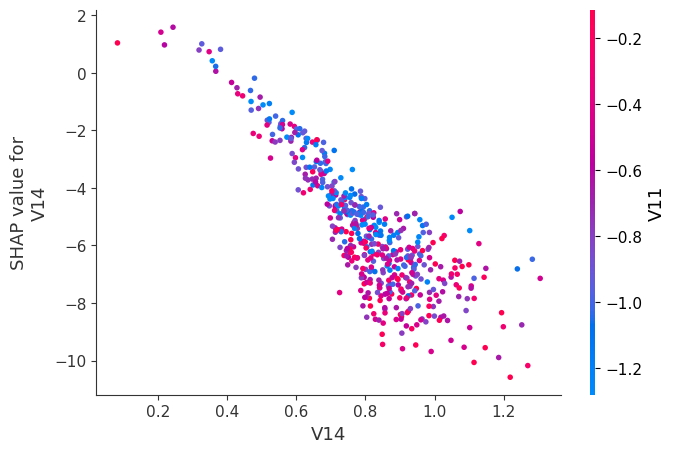

<Figure size 640x480 with 0 Axes>

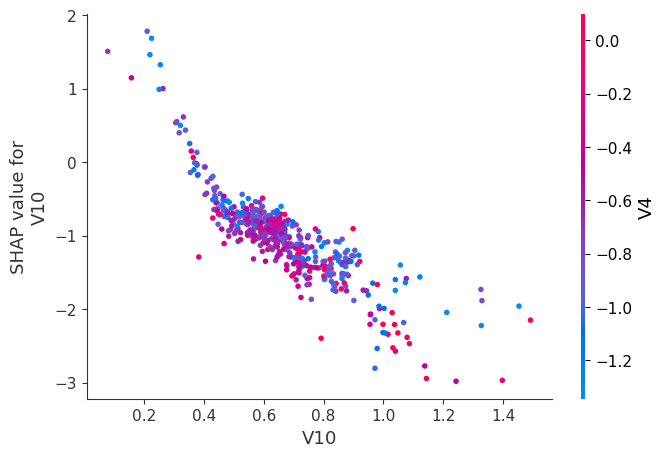

<Figure size 640x480 with 0 Axes>

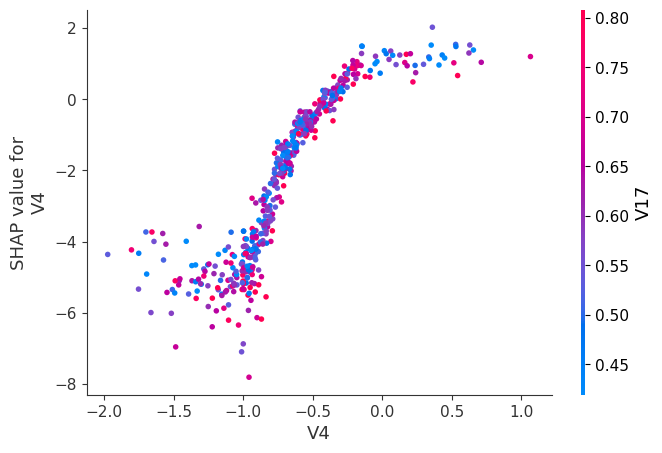

<Figure size 640x480 with 0 Axes>

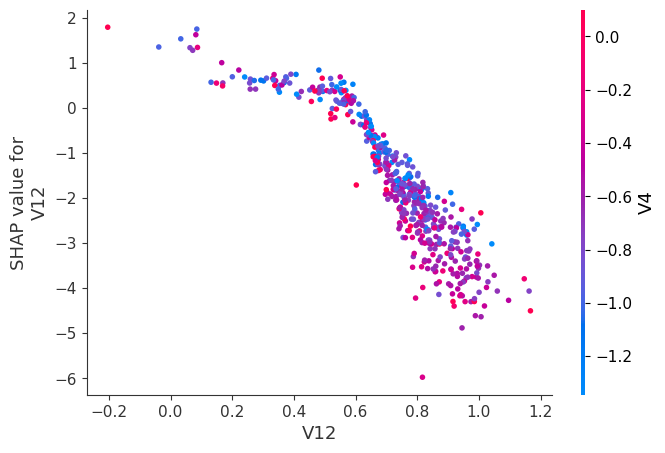

<Figure size 640x480 with 0 Axes>

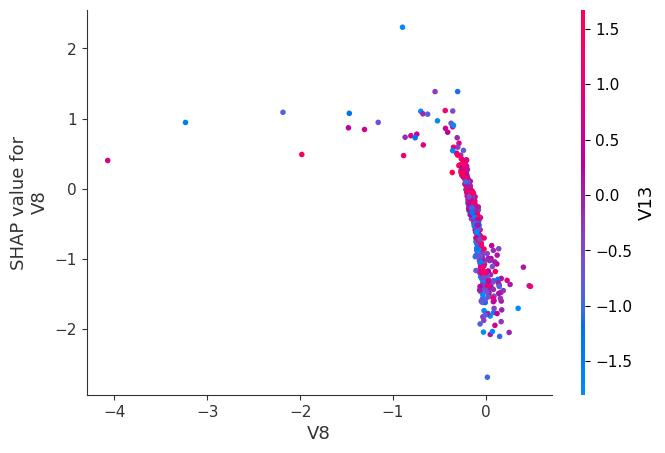

<Figure size 640x480 with 0 Axes>

In [29]:
# SHAP Analysis
import shap

explainer = shap.TreeExplainer(final_model)

sample_size = min(500, X_test_scaled.shape[0])
shap_values = explainer.shap_values(X_test_scaled[:sample_size])

# Plot Summary of All Features
shap.summary_plot(shap_values, X_test_scaled[:sample_size], 
                  feature_names=X_train.columns)
plt.savefig('shap_summary_plot.png')

# Analyse the Top 5 important features
for feature in X_train.columns[indices[:5]]: 
    shap.dependence_plot(feature, shap_values, X_test_scaled[:sample_size], 
                         feature_names=X_train.columns)
    plt.savefig(f'shap_dependence_plot_{feature}.png')

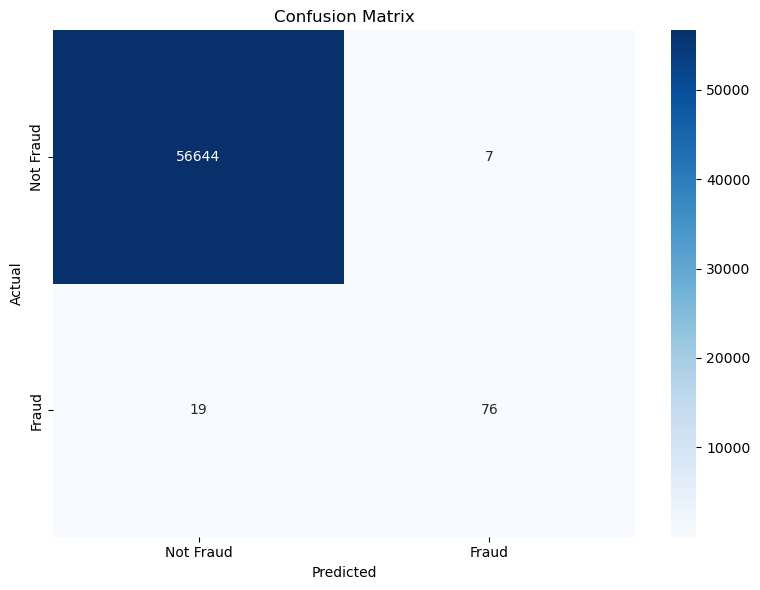

True Negatives: 56644 (0.9982)
False Positives: 7 (0.0001)
False Negatives: 19 (0.0003)
True Positives: 76 (0.0013)


In [33]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Fraud', 'Fraud'], 
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives: {tn} ({tn/(tn+fp+fn+tp):.4f})")
print(f"False Positives: {fp} ({fp/(tn+fp+fn+tp):.4f})")
print(f"False Negatives: {fn} ({fn/(tn+fp+fn+tp):.4f})")
print(f"True Positives: {tp} ({tp/(tn+fp+fn+tp):.4f})")

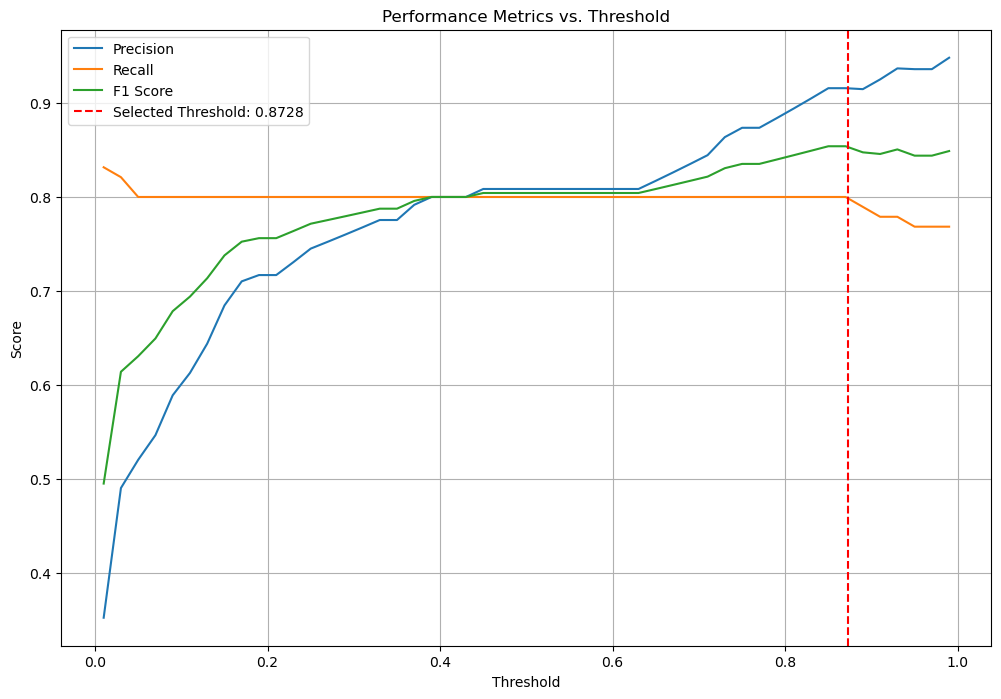

Selected threshold: 0.8728
At this threshold:
- Precision: 0.9157
- Recall: 0.8000
- F1 Score: 0.8539
- False Positive Rate: 0.0001


In [35]:
# Threshold Performance Visualization
thresholds = np.linspace(0.01, 0.99, 50)
results = []

for threshold in thresholds:
    y_pred_t = (y_prob >= threshold).astype(int)
    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    results.append([threshold, precision, recall, f1])

results_df = pd.DataFrame(results, columns=['Threshold', 'Precision', 'Recall', 'F1'])

plt.figure(figsize=(12, 8))
plt.plot(results_df['Threshold'], results_df['Precision'], label='Precision')
plt.plot(results_df['Threshold'], results_df['Recall'], label='Recall')
plt.plot(results_df['Threshold'], results_df['F1'], label='F1 Score')

# Label Best Threshold
plt.axvline(x=optimal_threshold, color='r', linestyle='--', 
            label=f'Selected Threshold: {optimal_threshold:.4f}')

plt.title('Performance Metrics vs. Threshold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

print(f"Selected threshold: {optimal_threshold:.4f}")
print("At this threshold:")
print(f"- Precision: {precision_score(y_test, y_pred):.4f}")
print(f"- Recall: {recall_score(y_test, y_pred):.4f}")
print(f"- F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"- False Positive Rate: {np.sum((y_pred == 1) & (y_test == 0))/np.sum(y_test == 0):.4f}")

In [37]:
print(results_df_stage2.columns)

Index(['threshold', 'precision', 'recall', 'f1_score', 'accuracy', 'auc_roc',
       'max_depth', 'learning_rate', 'n_estimators', 'subsample',
       'colsample_bytree', 'scale_pos_weight', 'min_child_weight', 'gamma'],
      dtype='object')


#### Parameter Performance Comparison Graph

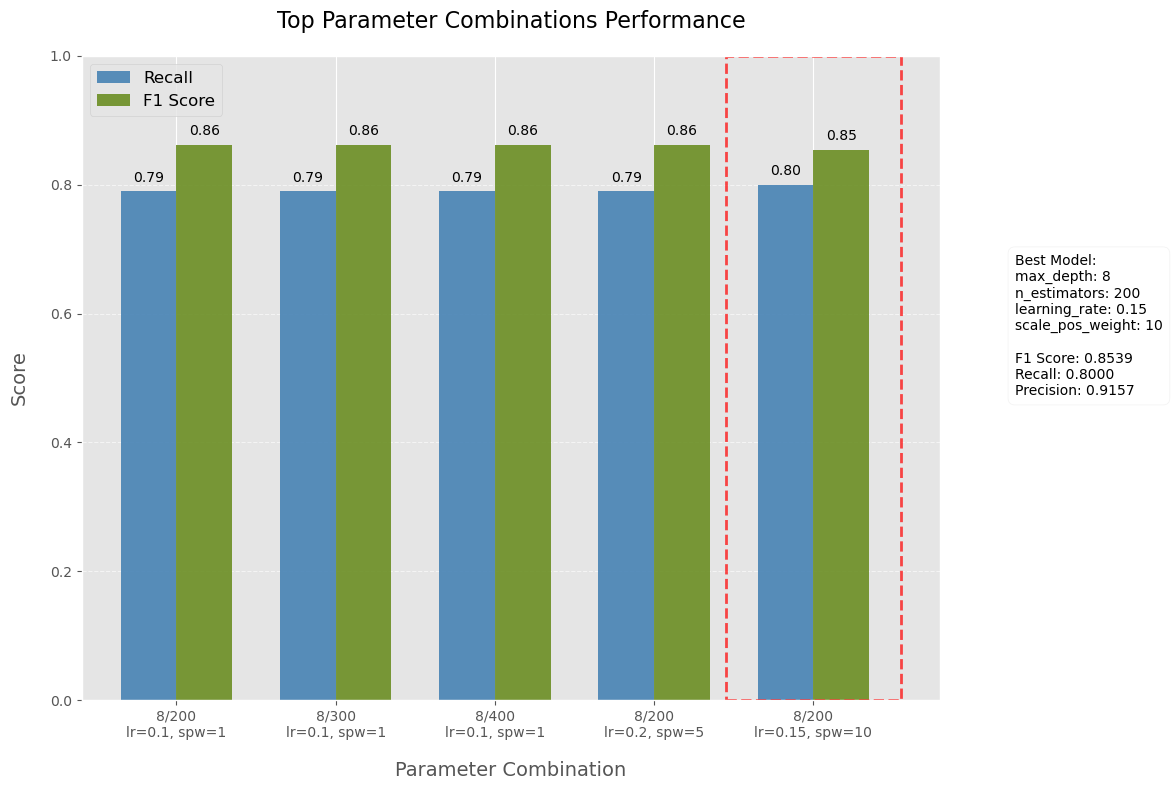

In [55]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Use the existing results_df_stage2 DataFrame
# Data columns: 'threshold', 'precision', 'recall', 'f1_score', 'accuracy', 'auc_roc',
# 'max_depth', 'learning_rate', 'n_estimators', 'subsample', 'colsample_bytree',
# 'scale_pos_weight', 'min_child_weight', 'gamma'

# 2. Create a simplified combination identifier (max_depth/n_estimators format) with learning rate and scale_pos_weight
results_df_stage2['combo'] = (
    results_df_stage2['max_depth'].astype(str) + '/' + 
    results_df_stage2['n_estimators'].astype(str) + '\n' +
    'lr=' + results_df_stage2['learning_rate'].astype(str) + ', ' +
    'spw=' + results_df_stage2['scale_pos_weight'].astype(str)
)

# 3. Find the best model
min_precision = 0.75
valid_models = results_df_stage2[results_df_stage2['precision'] >= min_precision]
max_recall = valid_models['recall'].max()
highest_recall_models = valid_models[valid_models['recall'] >= max_recall]
best_model = highest_recall_models.sort_values(by='f1_score', ascending=False).iloc[0]

# 4. Select only top models for visualization
# Sort all models by F1 score
df_sorted = results_df_stage2.sort_values(by='f1_score', ascending=False)

# Take top 5 models
top_n = 5
top_models = df_sorted.iloc[:top_n].copy()

# Check if best model is in top models
best_model_in_top = False
for idx, row in top_models.iterrows():
    if (row['max_depth'] == best_model['max_depth'] and 
        row['n_estimators'] == best_model['n_estimators'] and
        row['learning_rate'] == best_model['learning_rate'] and
        row['scale_pos_weight'] == best_model['scale_pos_weight']):
        best_model_in_top = True
        break

# If best model is not in top models, replace the last model
if not best_model_in_top:
    # Find the best model in the full dataset
    for idx, row in df_sorted.iterrows():
        if (row['max_depth'] == best_model['max_depth'] and 
            row['n_estimators'] == best_model['n_estimators'] and
            row['learning_rate'] == best_model['learning_rate'] and
            row['scale_pos_weight'] == best_model['scale_pos_weight']):
            best_idx = idx
            break
    
    # Replace the last model with the best model
    top_models = pd.concat([top_models.iloc[:-1], df_sorted.loc[[best_idx]]])

# 5. Create improved visualization

# 5.1 Set figure size and style
plt.figure(figsize=(12, 8))
plt.style.use('ggplot')

# 5.2 Set bar positions
x = np.arange(len(top_models))
width = 0.35  # wider bars

# 5.3 Draw bar charts (only show recall and F1 score)
bar1 = plt.bar(x - width/2, top_models['recall'], width, label='Recall', alpha=0.9, color='#4682B4')  # Steel Blue
bar2 = plt.bar(x + width/2, top_models['f1_score'], width, label='F1 Score', alpha=0.9, color='#6B8E23')  # Olive Drab

# 5.4 Find the best model position in the chart
best_model_index = -1
for i, (idx, row) in enumerate(top_models.iterrows()):
    if (row['max_depth'] == best_model['max_depth'] and 
        row['n_estimators'] == best_model['n_estimators'] and
        row['learning_rate'] == best_model['learning_rate'] and
        row['scale_pos_weight'] == best_model['scale_pos_weight']):
        best_model_index = i
        break

# 5.5 Add red rectangle around the best model
if best_model_index >= 0:
    # Remove the red dashed line and add a rectangle instead
    plt.gca().add_patch(plt.Rectangle(
        (best_model_index - width - 0.2, 0),  # x, y (bottom left corner)
        width*2 + 0.4, 1,  # width, height
        fill=False, edgecolor='red', linestyle='--', linewidth=2, alpha=0.7
    ))

# 5.6 Add chart title and axis labels
plt.title('Top Parameter Combinations Performance', fontsize=16, pad=20)
plt.xlabel('Parameter Combination', fontsize=14, labelpad=15)
plt.ylabel('Score', fontsize=14, labelpad=15)

# 5.7 Set x-axis ticks and labels
plt.xticks(x, top_models['combo'], fontsize=10)

# 5.8 Set y-axis range
plt.ylim(0, 1.0)

# 5.9 Add grid lines
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 5.10 Add legend
plt.legend(fontsize=12)

# 5.11 Add value labels on bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2f}', ha='center', va='bottom', fontsize=10)

add_labels(bar1)
add_labels(bar2)

# 5.12 Add information box about best model
info_text = (
    f"Best Model:\n"
    f"max_depth: {int(best_model['max_depth'])}\n"
    f"n_estimators: {int(best_model['n_estimators'])}\n"
    f"learning_rate: {best_model['learning_rate']}\n"
    f"scale_pos_weight: {int(best_model['scale_pos_weight'])}\n\n"
    f"F1 Score: {best_model['f1_score']:.4f}\n"
    f"Recall: {best_model['recall']:.4f}\n"
    f"Precision: {best_model['precision']:.4f}"
)

plt.figtext(0.85, 0.5, info_text, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'),
            fontsize=10, ha='left')

# 5.13 Adjust layout
plt.tight_layout(rect=[0, 0, 0.8, 1])

# 5.14 Save chart
plt.savefig('parameter_performance_comparison.png', dpi=300, bbox_inches='tight')

# Display chart
plt.show()

## Best Model

### Final Model & Training Time

In [41]:
import time

start_time = time.perf_counter()
final_model = XGBClassifier(
    max_depth=int(best_model_params['max_depth']),
    learning_rate=best_model_params['learning_rate'],
    n_estimators=int(best_model_params['n_estimators']),
    subsample=best_model_params['subsample'],
    colsample_bytree=best_model_params['colsample_bytree'],
    scale_pos_weight=int(best_model_params['scale_pos_weight']),
    min_child_weight=int(best_model_params['min_child_weight']),
    gamma=best_model_params['gamma'],
    eval_metric='logloss',
    random_state=42)

final_model.fit(X_train_scaled, y_train_resampled)

training_time = time.perf_counter() - start_time

# Apply the optimal threshold found
optimal_threshold = best_model_params['threshold']
y_prob = final_model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= optimal_threshold).astype(int)

print("\nBest XGBoost Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"Training Time: {training_time:.4f} s")


Best XGBoost Model Performance:
Accuracy: 0.9995
Precision: 0.9157
Recall: 0.8000
F1 Score: 0.8539
AUC-ROC: 0.9667
Optimal Threshold: 0.8728
Training Time: 8.4566 s


#### BEST Model without Imbalance Strategy

In [49]:
start_time = time.perf_counter()
final_model = XGBClassifier(
    max_depth=int(best_model_params['max_depth']),
    learning_rate=best_model_params['learning_rate'],
    n_estimators=int(best_model_params['n_estimators']),
    subsample=best_model_params['subsample'],
    colsample_bytree=best_model_params['colsample_bytree'],
    scale_pos_weight=int(best_model_params['scale_pos_weight']),
    min_child_weight=int(best_model_params['min_child_weight']),
    gamma=best_model_params['gamma'],
    eval_metric='logloss',
    random_state=42)

final_model.fit(X_train, y_train)

training_time = time.perf_counter() - start_time

# Apply the optimal threshold found
optimal_threshold = best_model_params['threshold']
y_prob = final_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= optimal_threshold).astype(int)

print("\nBest XGBoost Model Performance Without Imbalance Strategy:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"Training Time: {training_time:.4f} s")


Best XGBoost Model Performance Without Imbalance Strategy:
Accuracy: 0.9996
Precision: 0.9861
Recall: 0.7474
F1 Score: 0.8503
AUC-ROC: 0.9776
Optimal Threshold: 0.8728
Training Time: 4.5841 s


#### Original Model without Imbalance Strategy

In [51]:
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
print("\nXGBoost Performance Without Imbalance Strategy:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_xgb):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.4f}")


XGBoost Performance Without Imbalance Strategy:
Accuracy: 0.9993
Precision: 0.8140
Recall: 0.7368
F1-score: 0.7735
AUC-ROC: 0.9248


#### Heat Map

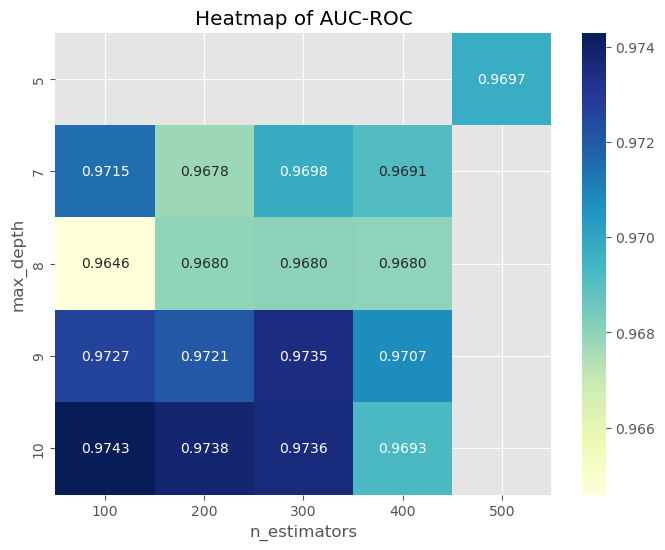

In [65]:
# Heatmap Of AUC-ROC
import matplotlib.pyplot as plt
import seaborn as sns
# Aggregate the duplicate rows by taking the mean of auc_roc for each combination of max_depth and n_estimators
results_df_auc = results_df_stage2.groupby(['max_depth', 'n_estimators'], as_index=False).agg({'auc_roc': 'mean'})

# Now try pivoting again
auc_matrix_xgb = results_df_auc.pivot(index='max_depth', columns='n_estimators', values='auc_roc')
plt.figure(figsize=(8,6))
sns.heatmap(auc_matrix_xgb, annot=True, fmt=".4f", cmap="YlGnBu")
plt.title('Heatmap of AUC-ROC')
plt.xlabel('n_estimators')
plt.ylabel('max_depth')
plt.show()


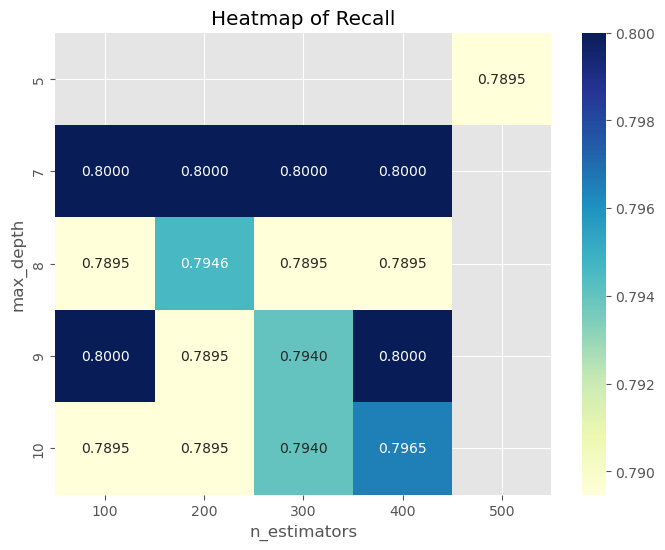

In [67]:
# Heatmap Of Recall
# Aggregate the duplicate rows by taking the mean of auc_roc for each combination of max_depth and n_estimators
results_df_recall = results_df_stage2.groupby(['max_depth', 'n_estimators'], as_index=False).agg({'recall': 'mean'})

# Now try pivoting again
recall_matrix_xgb = results_df_recall.pivot(index='max_depth', columns='n_estimators', values='recall')
plt.figure(figsize=(8,6))
sns.heatmap(recall_matrix_xgb, annot=True, fmt=".4f", cmap="YlGnBu")
plt.title('Heatmap of Recall')
plt.xlabel('n_estimators')
plt.ylabel('max_depth')
plt.show()


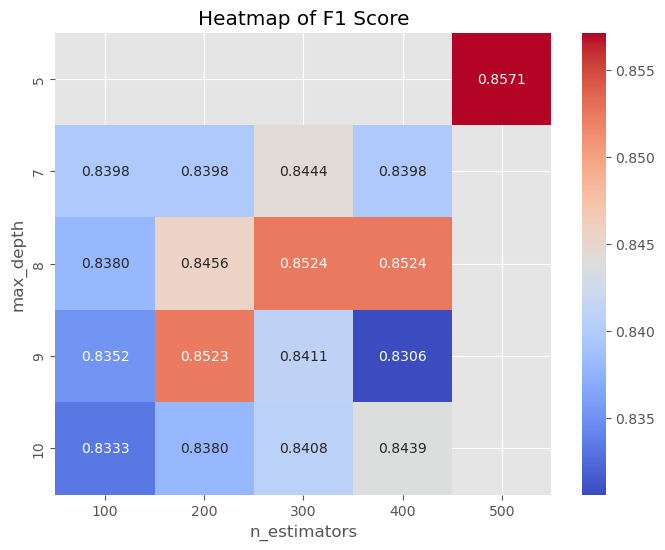

In [69]:
# Heatmap Of F1 Score
# Aggregate the duplicate rows by taking the mean of auc_roc for each combination of max_depth and n_estimators
results_df_f1 = results_df_stage2.groupby(['max_depth', 'n_estimators'], as_index=False).agg({'f1_score': 'mean'})

# Now try pivoting again
f1_matrix_xgb = results_df_f1.pivot(index='max_depth', columns='n_estimators', values='f1_score')
plt.figure(figsize=(8,6))
sns.heatmap(f1_matrix_xgb, annot=True, fmt=".4f", cmap="coolwarm")
plt.title('Heatmap of F1 Score')
plt.xlabel('n_estimators')
plt.ylabel('max_depth')
plt.show()
